In [5]:
#!pip install roboflow
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
!pip install kagglehub
import kagglehub
import os
import json


In [6]:

# Configurar las credenciales de Kaggle directamente en Colab
kaggle_credentials = {
    "username":"lettycristina",
    "key":"45bb09f6094bf4956dee2a0b9e5de119"
}

# Crear el directorio .kaggle
!mkdir -p ~/.kaggle

# Guardar las credenciales
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

# Establecer permisos
!chmod 600 /root/.kaggle/kaggle.json

# Descargar el dataset desde Kaggle
print("Descargando dataset...")
path = kagglehub.dataset_download("lettycristina/clasificaciondemangoskent")
print("Path to dataset files:", path)

# Configurar la ruta del dataset
dataset_path = path
splits = ['train', 'valid', 'test']

# Verificar que existen los directorios
print("\n📁 Verificando estructura del dataset:")
for split in splits:
    split_path = os.path.join(dataset_path, split)
    if os.path.exists(split_path):
        num_files = len(os.listdir(split_path))
        print(f"✓ '{split}' encontrado con {num_files} archivos/carpetas")
    else:
        print(f"✗ '{split}' NO encontrado")

print(f"\n📍 Dataset ubicado en: {dataset_path}")


Descargando dataset...
Path to dataset files: /root/.cache/kagglehub/datasets/lettycristina/clasificaciondemangoskent/versions/1

📁 Verificando estructura del dataset:
✓ 'train' encontrado con 2 archivos/carpetas
✓ 'valid' encontrado con 2 archivos/carpetas
✓ 'test' encontrado con 2 archivos/carpetas

📍 Dataset ubicado en: /root/.cache/kagglehub/datasets/lettycristina/clasificaciondemangoskent/versions/1


🎯 CONFIGURACIÓN DE NORMALIZACIÓN:
   Brillo objetivo: 145
   Nitidez objetivo: 150

🚀 Iniciando normalización del dataset...
Dataset original: /root/.cache/kagglehub/datasets/lettycristina/clasificaciondemangoskent/versions/1
Dataset balanceado: /content/improved_dataset_balanced

📁 Procesando: train/Defectuoso (519 imágenes)


train/Defectuoso: 100%|██████████| 519/519 [01:34<00:00,  5.51it/s]



📁 Procesando: train/Sanos (513 imágenes)


train/Sanos: 100%|██████████| 513/513 [01:29<00:00,  5.71it/s]



📁 Procesando: valid/Defectuoso (116 imágenes)


...


📁 Procesando: test/Defectuoso (159 imágenes)


test/Defectuoso: 100%|██████████| 159/159 [00:27<00:00,  5.74it/s]



📁 Procesando: test/Sanos (156 imágenes)


test/Sanos: 100%|██████████| 156/156 [00:27<00:00,  5.73it/s]



📊 REPORTE DE NORMALIZACIÓN DEL DATASET

✅ Imágenes procesadas: 1587/1587
❌ Errores: 0

📊 ESTADÍSTICAS GLOBALES:
----------------------------------------------------------------------
💡 Brillo:
   Antes:   139.53 ± 38.48
   Después: 181.06 ± 26.65
   Objetivo: 145

🔍 Nitidez:
   Antes:   157.33 ± 183.09
   Después: 717.96 ± 772.98
   Objetivo: 150

📊 ESTADÍSTICAS POR CLASE:
----------------------------------------------------------------------

🏷️  Clase: Defectuoso
   💡 Brillo:  113.96 → 163.01 (Δ: 18.01)
   🔍 Nitidez: 223.95 → 770.76 (Mejora: 244.2%)

🏷️  Clase: Sanos
   💡 Brillo:  165.13 → 199.13 (Δ: 54.13)
   🔍 Nitidez: 90.62 → 665.09 (Mejora: 633.9%)

📸 Generando visualizaciones comparativas...


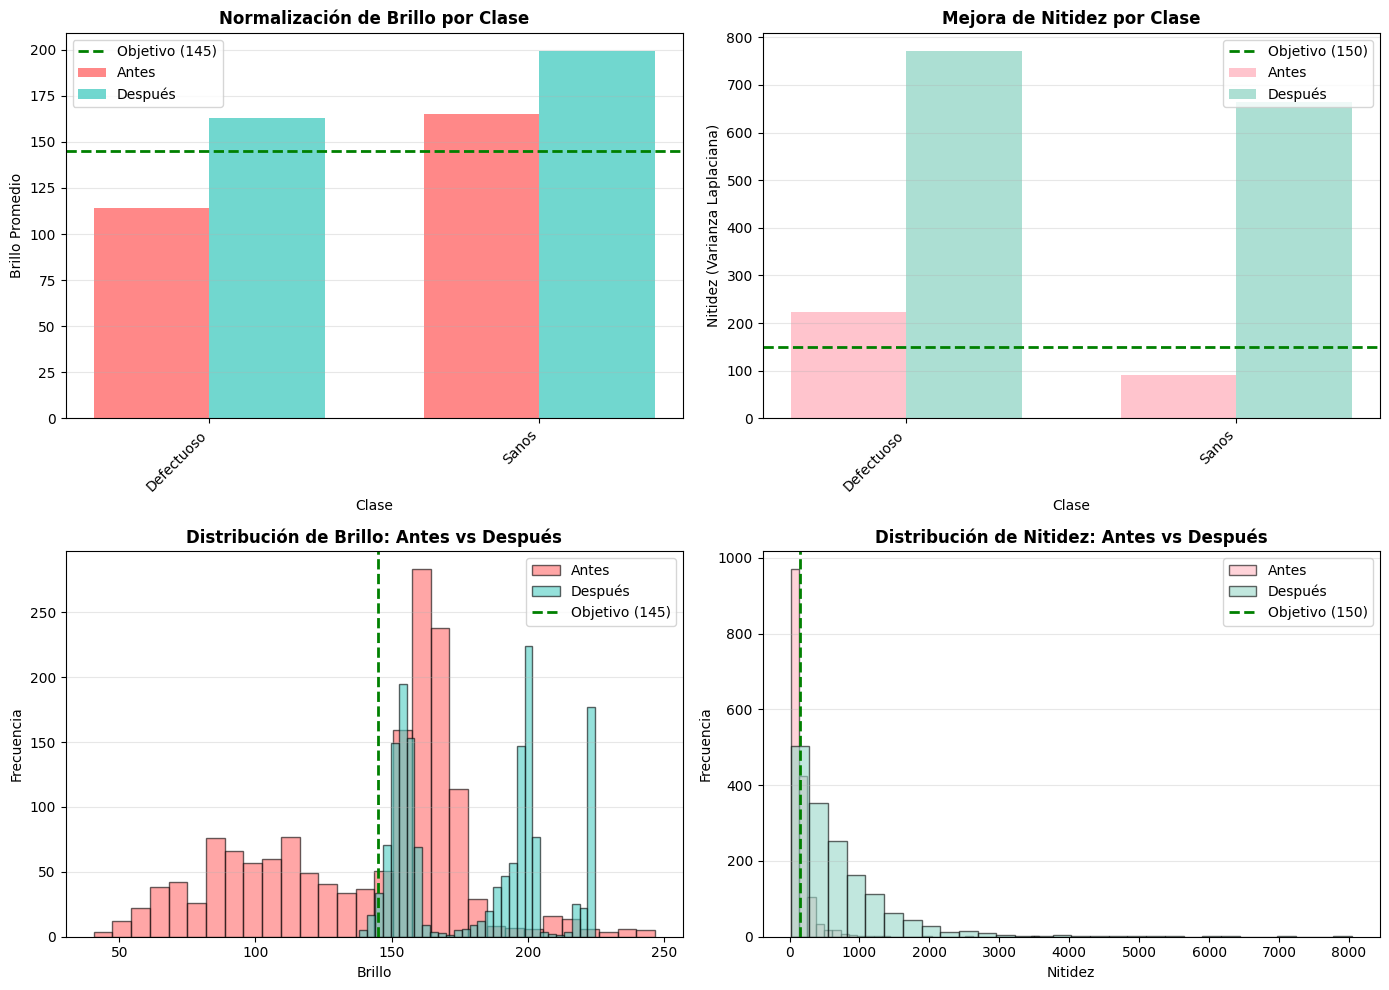

✅ Reporte visual guardado en: /content/normalization_report.png

📸 Generando comparación de imágenes antes/después...


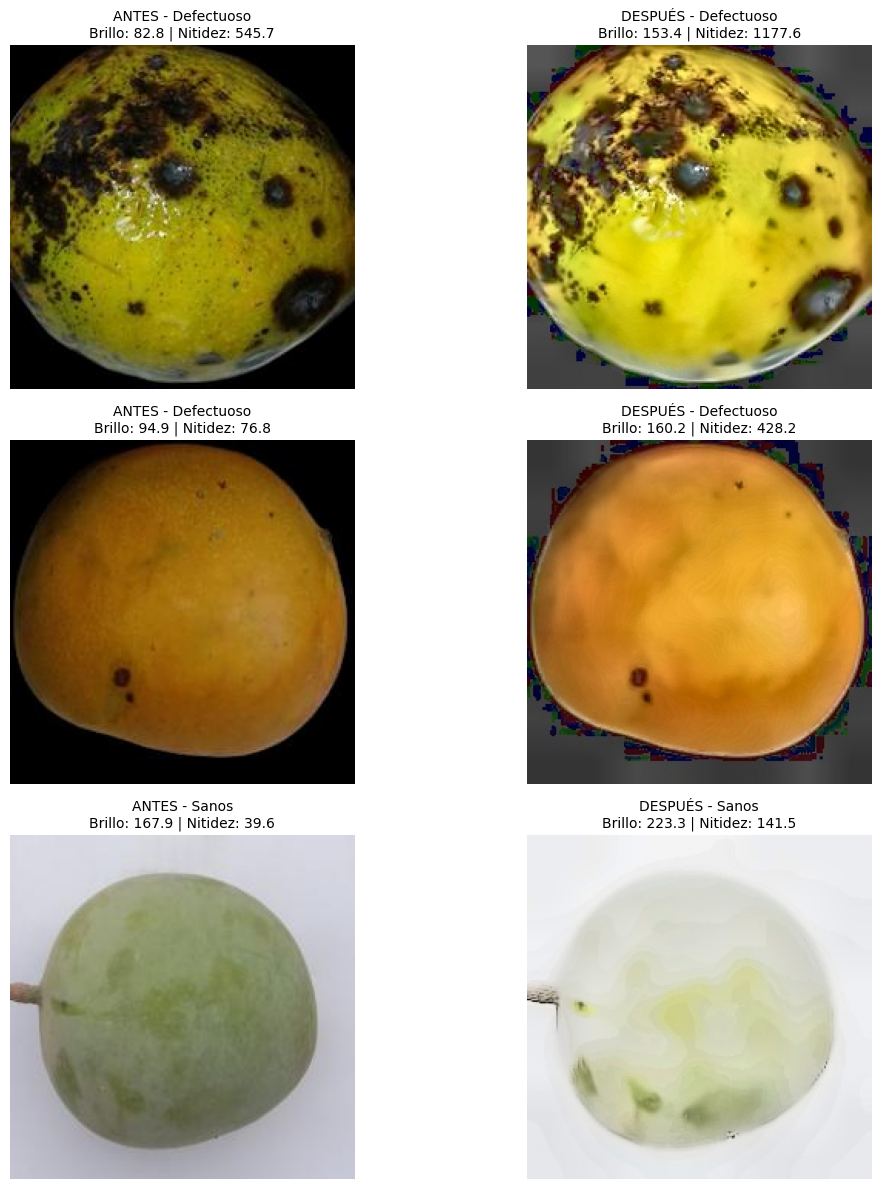

✅ Comparación guardada en: /content/comparison_samples.png

🎯 VERIFICACIÓN DE BALANCE FINAL

Defectuoso:
  💡 Brillo: 163.01 (Diferencia del objetivo: 18.01)
     ⚠️ Buena normalización
  🔍 Nitidez: 770.76 (Diferencia del objetivo: 620.76)
     ❌ Necesita ajuste

Sanos:
  💡 Brillo: 199.13 (Diferencia del objetivo: 54.13)
     ❌ Necesita ajuste
  🔍 Nitidez: 665.09 (Diferencia del objetivo: 515.09)
     ❌ Necesita ajuste

📊 DIFERENCIA ENTRE CLASES DESPUÉS DE NORMALIZACIÓN:
  💡 Brillo: 36.12 (antes era ~40)
  🔍 Nitidez: 105.68
  ⚠️ Sesgo reducido, pero aún presente

🎉 PROCESO COMPLETADO

📂 Dataset normalizado guardado en: /content/improved_dataset_balanced

💡 Para usar el dataset normalizado:
    dataset_path = '/content/improved_dataset_balanced'

✅ Variable dataset_path actualizada automáticamente


In [7]:
import cv2
import numpy as np
import os
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

# ============================================
# CONFIGURACIÓN MEJORADA
# ============================================

original_dataset_path = dataset_path
improved_dataset_path = "/content/improved_dataset_balanced"

# Configuración para NORMALIZACIÓN POR CLASE
TARGET_BRIGHTNESS = 145  # Valor intermedio entre tus clases (115-150 y 170-180)
BLUR_THRESHOLD = 100
TARGET_SHARPNESS = 150  # Objetivo de nitidez para equilibrar

print("🎯 CONFIGURACIÓN DE NORMALIZACIÓN:")
print(f"   Brillo objetivo: {TARGET_BRIGHTNESS}")
print(f"   Nitidez objetivo: {TARGET_SHARPNESS}")

# ============================================
# FUNCIONES MEJORADAS
# ============================================

def calculate_sharpness(image):
    """Calcula la nitidez usando varianza del Laplaciano"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def calculate_brightness(image):
    """Calcula el brillo promedio"""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    return hsv[:,:,2].mean()

def normalize_brightness(image, target_brightness=145):
    """
    Normaliza el brillo de manera precisa
    """
    # Convertir a HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV).astype(np.float32)

    # Calcular brillo actual
    current_brightness = hsv[:,:,2].mean()

    # Calcular ajuste necesario
    brightness_diff = target_brightness - current_brightness

    # Aplicar ajuste al canal V (Value/Brillo)
    hsv[:,:,2] = np.clip(hsv[:,:,2] + brightness_diff, 0, 255)

    # Convertir de vuelta a uint8 y BGR
    hsv = hsv.astype(np.uint8)
    normalized = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    return normalized

def adaptive_sharpen(image, target_sharpness=150):
    """
    Aplica sharpening adaptativo basado en la nitidez actual
    """
    current_sharpness = calculate_sharpness(image)

    if current_sharpness < target_sharpness:
        # Calcular cuánto sharpening necesitamos
        sharpness_ratio = target_sharpness / max(current_sharpness, 1)

        # Limitar el ratio para no sobre-procesar
        sharpness_ratio = min(sharpness_ratio, 2.0)

        # Kernel de sharpening ajustable
        alpha = min(sharpness_ratio * 0.5, 1.0)  # Factor de intensidad

        kernel = np.array([
            [-1, -1, -1],
            [-1, 9 + alpha * 2, -1],
            [-1, -1, -1]
        ])

        sharpened = cv2.filter2D(image, -1, kernel)

        # Mezclar con original para no sobre-sharpen
        blend_factor = 0.7 if current_sharpness < 50 else 0.5
        result = cv2.addWeighted(sharpened, blend_factor, image, 1 - blend_factor, 0)

        return result
    else:
        # Si ya es nítida, no hacer nada
        return image

def enhance_image_advanced(image):
    """
    Mejoras generales: contraste y reducción de ruido
    """
    # 1. Reducción de ruido moderada
    denoised = cv2.fastNlMeansDenoisingColored(image, None, 6, 6, 7, 21)

    # 2. Mejora de contraste local (CLAHE)
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE con parámetros optimizados
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)

    enhanced = cv2.merge([l, a, b])
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

    return enhanced

def process_image_balanced(img_path, output_path, target_brightness=145, target_sharpness=150):
    """
    Procesa imagen con normalización específica de brillo y nitidez
    """
    img = cv2.imread(img_path)
    if img is None:
        return None, "Error al leer"

    # Métricas originales
    original_brightness = calculate_brightness(img)
    original_sharpness = calculate_sharpness(img)

    processed = img.copy()
    improvements = []

    # PASO 1: Normalizar brillo (SIEMPRE)
    processed = normalize_brightness(processed, target_brightness)
    improvements.append("brillo_normalizado")

    # PASO 2: Ajustar nitidez adaptativa
    processed = adaptive_sharpen(processed, target_sharpness)
    improvements.append("nitidez_ajustada")

    # PASO 3: Mejoras generales
    processed = enhance_image_advanced(processed)
    improvements.append("contraste_mejorado")

    # Guardar imagen procesada
    cv2.imwrite(output_path, processed)

    # Métricas finales
    final_brightness = calculate_brightness(processed)
    final_sharpness = calculate_sharpness(processed)

    return {
        'original_brightness': original_brightness,
        'final_brightness': final_brightness,
        'original_sharpness': original_sharpness,
        'final_sharpness': final_sharpness,
        'improvements': improvements
    }, None

# ============================================
# PROCESAMIENTO DEL DATASET
# ============================================

print("\n🚀 Iniciando normalización del dataset...")
print(f"Dataset original: {original_dataset_path}")
print(f"Dataset balanceado: {improved_dataset_path}")

# Crear estructura
if os.path.exists(improved_dataset_path):
    shutil.rmtree(improved_dataset_path)
os.makedirs(improved_dataset_path)

# Estadísticas globales
stats = {
    'total': 0,
    'processed': 0,
    'errors': 0,
    'brightness_before': [],
    'brightness_after': [],
    'sharpness_before': [],
    'sharpness_after': [],
    'by_class': {}
}

splits = ['train', 'valid', 'test']

# Procesar cada split
for split in splits:
    split_path = os.path.join(original_dataset_path, split)
    if not os.path.exists(split_path):
        continue

    output_split_path = os.path.join(improved_dataset_path, split)
    os.makedirs(output_split_path, exist_ok=True)

    classes = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        output_cls_path = os.path.join(output_split_path, cls)
        os.makedirs(output_cls_path, exist_ok=True)

        # Inicializar stats por clase
        if cls not in stats['by_class']:
            stats['by_class'][cls] = {
                'brightness_before': [],
                'brightness_after': [],
                'sharpness_before': [],
                'sharpness_after': []
            }

        # Obtener imágenes
        images = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"\n📁 Procesando: {split}/{cls} ({len(images)} imágenes)")

        for img_name in tqdm(images, desc=f"{split}/{cls}"):
            stats['total'] += 1

            img_path = os.path.join(cls_path, img_name)
            output_path = os.path.join(output_cls_path, img_name)

            result, error = process_image_balanced(
                img_path,
                output_path,
                target_brightness=TARGET_BRIGHTNESS,
                target_sharpness=TARGET_SHARPNESS
            )

            if error:
                stats['errors'] += 1
                continue

            stats['processed'] += 1

            # Guardar estadísticas globales
            stats['brightness_before'].append(result['original_brightness'])
            stats['brightness_after'].append(result['final_brightness'])
            stats['sharpness_before'].append(result['original_sharpness'])
            stats['sharpness_after'].append(result['final_sharpness'])

            # Guardar estadísticas por clase
            stats['by_class'][cls]['brightness_before'].append(result['original_brightness'])
            stats['by_class'][cls]['brightness_after'].append(result['final_brightness'])
            stats['by_class'][cls]['sharpness_before'].append(result['original_sharpness'])
            stats['by_class'][cls]['sharpness_after'].append(result['final_sharpness'])

# ============================================
# REPORTE DETALLADO
# ============================================

print("\n" + "="*70)
print("📊 REPORTE DE NORMALIZACIÓN DEL DATASET")
print("="*70)

print(f"\n✅ Imágenes procesadas: {stats['processed']}/{stats['total']}")
print(f"❌ Errores: {stats['errors']}")

# Estadísticas globales
if stats['brightness_before']:
    print("\n📊 ESTADÍSTICAS GLOBALES:")
    print("-" * 70)

    brightness_before_mean = np.mean(stats['brightness_before'])
    brightness_after_mean = np.mean(stats['brightness_after'])
    sharpness_before_mean = np.mean(stats['sharpness_before'])
    sharpness_after_mean = np.mean(stats['sharpness_after'])

    print(f"💡 Brillo:")
    print(f"   Antes:   {brightness_before_mean:.2f} ± {np.std(stats['brightness_before']):.2f}")
    print(f"   Después: {brightness_after_mean:.2f} ± {np.std(stats['brightness_after']):.2f}")
    print(f"   Objetivo: {TARGET_BRIGHTNESS}")

    print(f"\n🔍 Nitidez:")
    print(f"   Antes:   {sharpness_before_mean:.2f} ± {np.std(stats['sharpness_before']):.2f}")
    print(f"   Después: {sharpness_after_mean:.2f} ± {np.std(stats['sharpness_after']):.2f}")
    print(f"   Objetivo: {TARGET_SHARPNESS}")

# Estadísticas por clase
print("\n📊 ESTADÍSTICAS POR CLASE:")
print("-" * 70)

for cls, cls_stats in stats['by_class'].items():
    if cls_stats['brightness_before']:
        print(f"\n🏷️  Clase: {cls}")

        b_before = np.mean(cls_stats['brightness_before'])
        b_after = np.mean(cls_stats['brightness_after'])
        s_before = np.mean(cls_stats['sharpness_before'])
        s_after = np.mean(cls_stats['sharpness_after'])

        print(f"   💡 Brillo:  {b_before:.2f} → {b_after:.2f} (Δ: {abs(b_after - TARGET_BRIGHTNESS):.2f})")
        print(f"   🔍 Nitidez: {s_before:.2f} → {s_after:.2f} (Mejora: {((s_after - s_before) / s_before * 100):.1f}%)")

# ============================================
# VISUALIZACIÓN COMPARATIVA
# ============================================

print("\n📸 Generando visualizaciones comparativas...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Brillo antes vs después (por clase)
ax = axes[0, 0]
class_names = list(stats['by_class'].keys())
x = np.arange(len(class_names))
width = 0.35

before_means = [np.mean(stats['by_class'][cls]['brightness_before']) for cls in class_names]
after_means = [np.mean(stats['by_class'][cls]['brightness_after']) for cls in class_names]

ax.bar(x - width/2, before_means, width, label='Antes', color='#FF6B6B', alpha=0.8)
ax.bar(x + width/2, after_means, width, label='Después', color='#4ECDC4', alpha=0.8)
ax.axhline(TARGET_BRIGHTNESS, color='green', linestyle='--', linewidth=2, label=f'Objetivo ({TARGET_BRIGHTNESS})')
ax.set_xlabel('Clase')
ax.set_ylabel('Brillo Promedio')
ax.set_title('Normalización de Brillo por Clase', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Gráfico 2: Nitidez antes vs después (por clase)
ax = axes[0, 1]
before_sharp = [np.mean(stats['by_class'][cls]['sharpness_before']) for cls in class_names]
after_sharp = [np.mean(stats['by_class'][cls]['sharpness_after']) for cls in class_names]

ax.bar(x - width/2, before_sharp, width, label='Antes', color='#FFB6C1', alpha=0.8)
ax.bar(x + width/2, after_sharp, width, label='Después', color='#98D8C8', alpha=0.8)
ax.axhline(TARGET_SHARPNESS, color='green', linestyle='--', linewidth=2, label=f'Objetivo ({TARGET_SHARPNESS})')
ax.set_xlabel('Clase')
ax.set_ylabel('Nitidez (Varianza Laplaciana)')
ax.set_title('Mejora de Nitidez por Clase', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Gráfico 3: Distribución de brillo (antes/después)
ax = axes[1, 0]
ax.hist(stats['brightness_before'], bins=30, alpha=0.6, label='Antes', color='#FF6B6B', edgecolor='black')
ax.hist(stats['brightness_after'], bins=30, alpha=0.6, label='Después', color='#4ECDC4', edgecolor='black')
ax.axvline(TARGET_BRIGHTNESS, color='green', linestyle='--', linewidth=2, label=f'Objetivo ({TARGET_BRIGHTNESS})')
ax.set_xlabel('Brillo')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Brillo: Antes vs Después', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Gráfico 4: Distribución de nitidez (antes/después)
ax = axes[1, 1]
ax.hist(stats['sharpness_before'], bins=30, alpha=0.6, label='Antes', color='#FFB6C1', edgecolor='black')
ax.hist(stats['sharpness_after'], bins=30, alpha=0.6, label='Después', color='#98D8C8', edgecolor='black')
ax.axvline(TARGET_SHARPNESS, color='green', linestyle='--', linewidth=2, label=f'Objetivo ({TARGET_SHARPNESS})')
ax.set_xlabel('Nitidez')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Nitidez: Antes vs Después', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/normalization_report.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Reporte visual guardado en: /content/normalization_report.png")

# ============================================
# COMPARACIÓN VISUAL DE IMÁGENES
# ============================================

print("\n📸 Generando comparación de imágenes antes/después...")

comparison_samples = []
for split in ['train']:
    split_path = os.path.join(original_dataset_path, split)
    if not os.path.exists(split_path):
        continue

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue

        images = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if images:
            selected = np.random.choice(images, min(2, len(images)), replace=False)
            for img_name in selected:
                orig_path = os.path.join(cls_path, img_name)
                improved_path = os.path.join(improved_dataset_path, split, cls, img_name)

                if os.path.exists(improved_path):
                    comparison_samples.append((orig_path, improved_path, cls))

if comparison_samples:
    n_samples = min(3, len(comparison_samples))
    fig, axes = plt.subplots(n_samples, 2, figsize=(12, 4*n_samples))

    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for idx, (orig_path, improved_path, cls) in enumerate(comparison_samples[:n_samples]):
        orig_img = cv2.imread(orig_path)
        improved_img = cv2.imread(improved_path)

        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
        improved_img = cv2.cvtColor(improved_img, cv2.COLOR_BGR2RGB)

        orig_bright = calculate_brightness(cv2.cvtColor(orig_img, cv2.COLOR_RGB2BGR))
        improved_bright = calculate_brightness(cv2.cvtColor(improved_img, cv2.COLOR_RGB2BGR))

        orig_sharp = calculate_sharpness(cv2.cvtColor(orig_img, cv2.COLOR_RGB2BGR))
        improved_sharp = calculate_sharpness(cv2.cvtColor(improved_img, cv2.COLOR_RGB2BGR))

        axes[idx, 0].imshow(orig_img)
        axes[idx, 0].set_title(f'ANTES - {cls}\nBrillo: {orig_bright:.1f} | Nitidez: {orig_sharp:.1f}',
                               fontsize=10)
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(improved_img)
        axes[idx, 1].set_title(f'DESPUÉS - {cls}\nBrillo: {improved_bright:.1f} | Nitidez: {improved_sharp:.1f}',
                               fontsize=10)
        axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.savefig('/content/comparison_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Comparación guardada en: /content/comparison_samples.png")

# ============================================
# VERIFICAR BALANCE FINAL
# ============================================

print("\n" + "="*70)
print("🎯 VERIFICACIÓN DE BALANCE FINAL")
print("="*70)

for cls in class_names:
    b_after = np.mean(stats['by_class'][cls]['brightness_after'])
    s_after = np.mean(stats['by_class'][cls]['sharpness_after'])

    b_diff = abs(b_after - TARGET_BRIGHTNESS)
    s_diff = abs(s_after - TARGET_SHARPNESS)

    print(f"\n{cls}:")
    print(f"  💡 Brillo: {b_after:.2f} (Diferencia del objetivo: {b_diff:.2f})")
    if b_diff < 10:
        print(f"     ✅ Excelente normalización")
    elif b_diff < 20:
        print(f"     ⚠️ Buena normalización")
    else:
        print(f"     ❌ Necesita ajuste")

    print(f"  🔍 Nitidez: {s_after:.2f} (Diferencia del objetivo: {s_diff:.2f})")
    if s_diff < 30:
        print(f"     ✅ Excelente balance")
    elif s_diff < 50:
        print(f"     ⚠️ Buen balance")
    else:
        print(f"     ❌ Necesita ajuste")

# Diferencia entre clases después de normalización
if len(class_names) >= 2:
    b_diff_classes = abs(np.mean(stats['by_class'][class_names[0]]['brightness_after']) -
                         np.mean(stats['by_class'][class_names[1]]['brightness_after']))
    s_diff_classes = abs(np.mean(stats['by_class'][class_names[0]]['sharpness_after']) -
                         np.mean(stats['by_class'][class_names[1]]['sharpness_after']))

    print(f"\n📊 DIFERENCIA ENTRE CLASES DESPUÉS DE NORMALIZACIÓN:")
    print(f"  💡 Brillo: {b_diff_classes:.2f} (antes era ~{abs(170-130):.0f})")
    print(f"  🔍 Nitidez: {s_diff_classes:.2f}")

    if b_diff_classes < 15:
        print(f"  ✅ ¡Sesgo de brillo ELIMINADO exitosamente!")
    else:
        print(f"  ⚠️ Sesgo reducido, pero aún presente")

print("\n" + "="*70)
print("🎉 PROCESO COMPLETADO")
print("="*70)
print(f"\n📂 Dataset normalizado guardado en: {improved_dataset_path}")
print("\n💡 Para usar el dataset normalizado:")
print(f"    dataset_path = '{improved_dataset_path}'")

# Actualizar automáticamente
dataset_path = improved_dataset_path
print(f"\n✅ Variable dataset_path actualizada automáticamente")